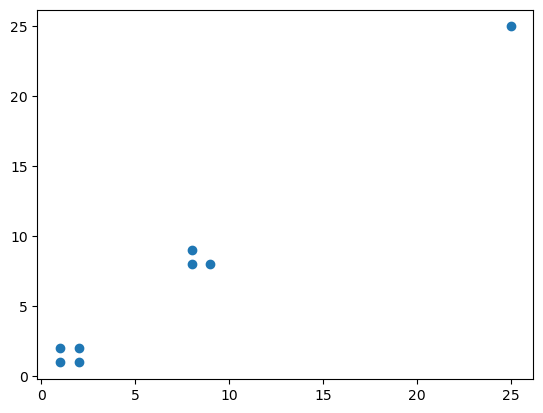

In [1]:
import numpy as np
import matplotlib.pyplot as plt
X = np.array(
    [[1,1],[1,2],[2,1],[2,2],[8,8],[8,9],[9,8],[25,25]]
)
plt.scatter(X[:,0] , X[:,1])
plt.show()

In [2]:
esp = 1.5
min_sample = 3
round(np.sqrt((2-1)**2 + (2-1)**2),1)

np.float64(1.4)

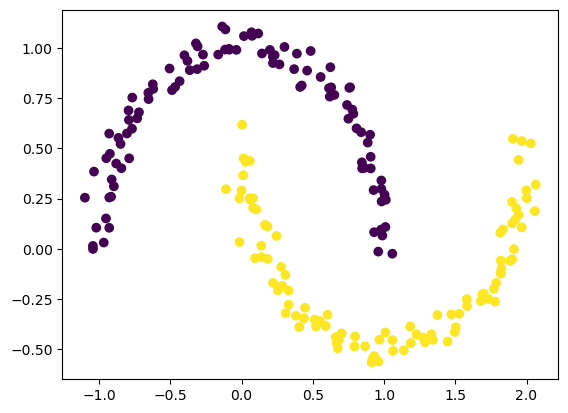

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

np.random.seed(42)

X,y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=42)

plt.scatter(X[:,0] , X[:,1] , c=y)
plt.show()

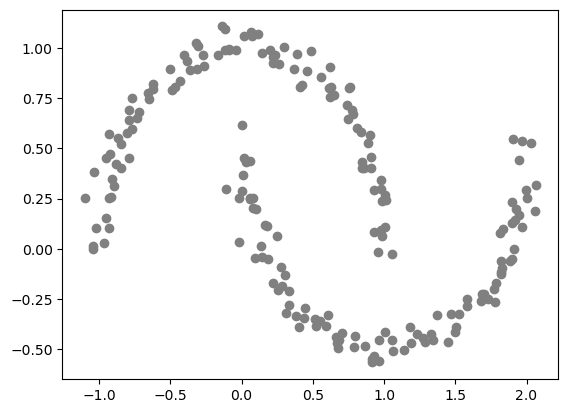

In [4]:
# step 1 초기화(모든점 미방문)
UNVISITED = -1
NOISE = -2
n = len(X)
labels = np.full(n, UNVISITED)

esp = 0.3
min_samples = 5
cluster_id = 0
plt.scatter(X[:,0], X[:,1],c='gray')
plt.show()

In [5]:
# step 2 : 반경내 이웃찾기
def region_query(X, point_idx, esp):
    '''
    X : 전체데이터셋
    point_idx : 기준점 Core point후보 인덱스
    eps : 이웃으로인정하기위한 최대거리 즉 반경(Epsilon)
    반환값 : neighbors, 가장거리가먼 max_neighbors
    '''
    distance = np.linalg.norm(    
        X - X[point_idx],
        axis=1  # 열단위로 연산
    )
    neighbors = np.where(distance <= esp)[0]       
    max_neighbors =  np.argmax(X[neighbors])
    return neighbors, max_neighbors

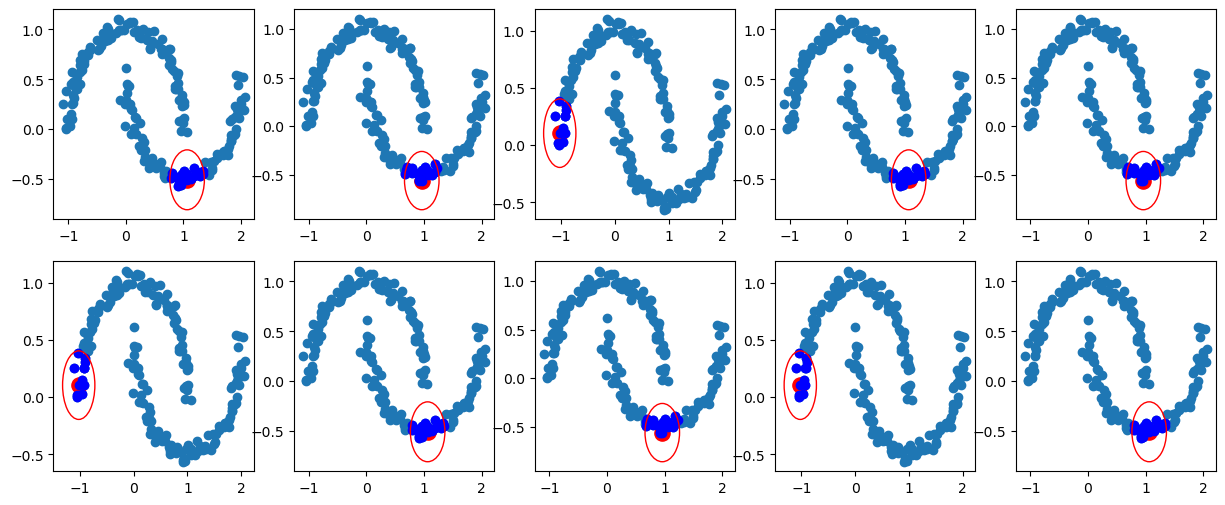

In [6]:
neighbors, max_neighbors = region_query(X, 0, esp)
esp = 0.3
fig, ax = plt.subplots(2,5,figsize=(15,6))
for i in range(10):
    point_index = max_neighbors
    
    neighbors, max_neighbors = region_query(X, point_index, esp)
    
    # 전체점
    ax[i//5, i%5].scatter(X[:,0], X[:,1])

    # 현재 점
    ax[i//5, i%5].scatter(
        X[point_index,0], X[point_index,1],
        c='red',s=120
    )
    # 이웃점
    ax[i//5, i%5].scatter(
        X[neighbors,0], X[neighbors,1],
        c='blue'
    )   

    # esp 원
    circle = plt.Circle(
        X[point_index], esp, color='red',fill=False
    )
    ax[i//5, i%5].add_patch(circle)
plt.show()

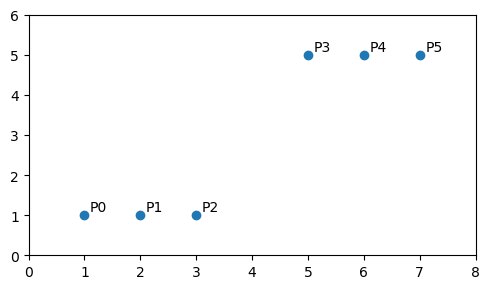

In [7]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5,3))
# 사슬모양
X = np.array([
    [1,1],[2,1],[3,1],[5,5],[6,5],[7,5]
])
plt.scatter(X[:,0], X[:,1])
for i, (x,y) in enumerate(X):
    plt.text(x+0.1,y+0.1,f'P{i}')
plt.ylim(0,6)  
plt.xlim(0,8)
plt.tight_layout()

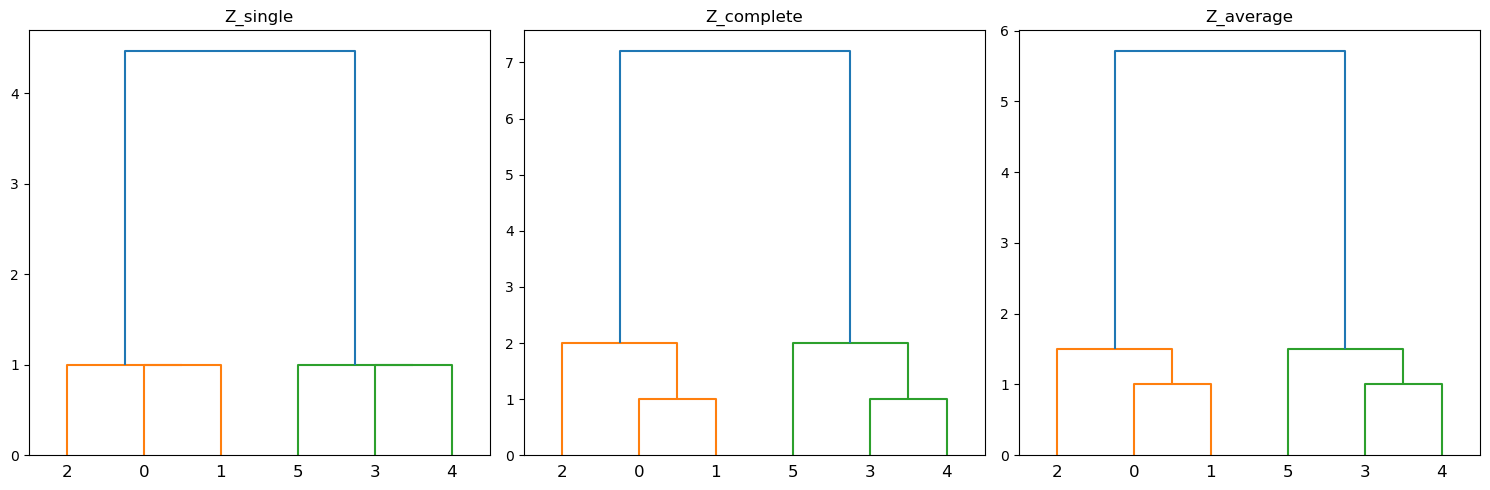

In [8]:
from scipy.cluster.hierarchy import linkage
Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')
Z_average = linkage(X, method='average')

from scipy.cluster.hierarchy import dendrogram
fig,ax = plt.subplots(1,3,figsize=(15,5))
dendrogram(Z_single, ax = ax[0])
dendrogram(Z_complete, ax = ax[1])
dendrogram(Z_average, ax = ax[2])
ax[0].set_title('Z_single');ax[1].set_title('Z_complete');ax[2].set_title('Z_average')
plt.tight_layout()
plt.show()

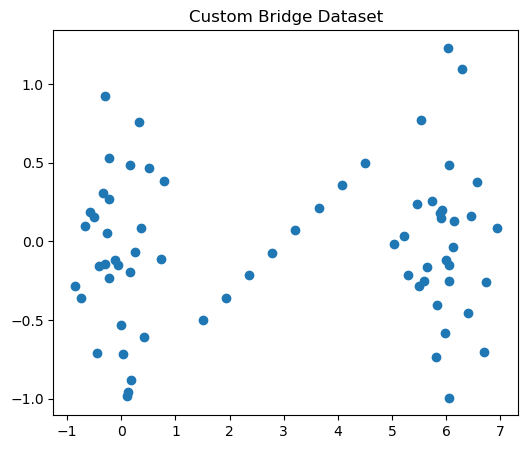

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

np.random.seed(42)
# 왼쪽 cluster
X1, _ = make_blobs(
    n_samples=30,
    centers=[[0,0]],
    cluster_std=0.5
)

# 오른쪽 cluster
X2, _ = make_blobs(
    n_samples=30,
    centers=[[6,0]],
    cluster_std=0.5
)

# 대각선 bridge 생성 (핵심)
bridge_x = np.linspace(1.5, 4.5, 8)
bridge_y = np.linspace(-0.5, 0.5, 8)
bridge = np.column_stack([
    bridge_x,
    bridge_y
])

X = np.vstack([X1, X2, bridge])
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1])
plt.title("Custom Bridge Dataset")
plt.show()

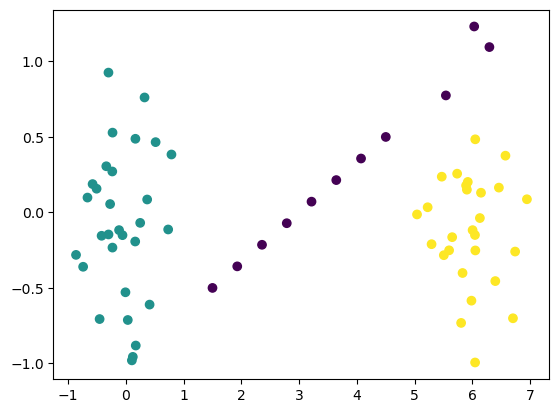

In [10]:
# 라이브러리 이용
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=0.5, min_samples=5)
sk_labels = model.fit_predict(X)
plt.scatter(
    X[:,0], X[:,1], c=sk_labels
)
plt.show()